In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pathlib
import torch
import lightning as L
from lightning_fabric.strategies import dp

import models
import loss
import datasets

In [2]:
data = pd.read_csv('results.csv')
data = data[data['scale_factor'] == 16]

In [3]:
unc = data.loc[(data['hard'] == 0) & (data['soft'] == 0)]
unc.loc[unc['rmse'] == unc['rmse'].min()]

,experiment,group,scale_factor,alpha,mae,rmse,features,residual_blocks,model,patience,lr,wd,soft,hard,version,resampling,data,parameters,exp_group
17,469,1,16,NaN,0.02983,0.04135,128,64,EDSR,15,0.0001,0.00001,0,0,mae,cubic_spline,ReKIS,21402113,1


In [5]:
soft = data.loc[(data['hard'] == 0) & (data['soft'] == 1)]
soft.loc[soft['rmse'] == soft['rmse'].min()]

,experiment,group,scale_factor,alpha,mae,rmse,features,residual_blocks,model,patience,lr,wd,soft,hard,version,resampling,data,parameters,exp_group
83,506,3,16,0.0001,0.02709,0.0358,128,64,EDSR,15,0.0001,0.00001,1,0,mae,average,ReKIS,21402113,3
104,525,3,16,0.0001,0.02709,0.0358,128,64,EDSR,15,0.0001,0.00001,1,0,mae,average,ReKIS,21402113,4


In [6]:
hard = data.loc[(data['hard'] == 1) & (data['soft'] == 0)]
hard.loc[hard['rmse'] == hard['rmse'].min()]

,experiment,group,scale_factor,alpha,mae,rmse,features,residual_blocks,model,patience,lr,wd,soft,hard,version,resampling,data,parameters,exp_group
78,629,12,16,NaN,0.02603,0.0315,128,64,EDSR,15,0.0001,0.00001,0,1,mae,average,ReKIS,21402113,2


In [2]:
CKPT_DIR = '/home/tomas/ctu/current/rci_home/SISR-downscaling/logs/lightning_logs/'
def load_checkpoint(version: int):
    dir = pathlib.Path(CKPT_DIR + f'version_{version}/checkpoints/')
    return [file for file in dir.iterdir() if file.is_file() and file.suffix == '.ckpt'][0]

torch.set_float32_matmul_precision("high")
ckpt = load_checkpoint(629)

model = models.ConstrainedModel.load_from_checkpoint(checkpoint_path = ckpt,
                                                     model=models.EDSR(channels=1, scale_factor=16, features=128, residual_blocks=64, loss=loss.LossCombination([1], [loss.L1Loss()])),
                                                     constraint=models.AddConstraintLayer(16)).cuda()
model.eval()

/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'constraint' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['constraint'])`.


ConstrainedModel(
  (train_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=train/
  )
  (val_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=val/
  )
  (test_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=test/
  )
  (model): EDSR(
    (train_metrics): MetricCollection(
      (mae): MeanAbsoluteError()
      (mse): MeanSquaredError()
      (rmse): MeanSquaredError(),
      prefix=train/
    )
    (val_metrics): MetricCollection(
      (mae): MeanAbsoluteError()
      (mse): MeanSquaredError()
      (rmse): MeanSquaredError(),
      prefix=val/
    )
    (test_metrics): MetricCollection(
      (mae): MeanAbsoluteError()
      (mse): MeanSquaredError()
      (rmse): MeanSquaredError(),
      prefix=test/
    )
    (loss): LossCombination(


In [3]:
import lightning
import rasterio
import torch
import xarray

# Average resampling used to reduce resolution
RESAMPLING = rasterio.enums.Resampling.average


class ReKIS(torch.utils.data.Dataset):
    """Dataset for ReKIS."""

    def __init__(self, Y: xarray.DataArray, scale_factor : int):
        """
        Initialize the dataset with target.
        The target is upscaled and used as input for the model.
        Args:
            Y : xarray.DataArray    target variable
            scale_factor : int
        """
        self.scale_factor = scale_factor

        Y = Y.isel(easting=slice(0, 400), northing=slice(0, 400))
        Y.rio.set_spatial_dims("easting", "northing")

        resolution = 1000 * self.scale_factor
        X = Y.rio.reproject(
            Y.rio.crs, resolution=(resolution, resolution), resampling=RESAMPLING
        )
        self.X = torch.from_numpy(X.values).unsqueeze(1)
        self.Y = torch.from_numpy(Y.values).unsqueeze(1)


    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, index: int):
        return self.X[index], self.Y[index]


class ReKISDataModule(lightning.LightningDataModule):
    """DataModule for ReKIS."""

    def __init__(self, batch_size: int, path: str, sets_years: list, scale_factor : int):
        """
        Initialize the DataModule.
        Args:
            batch_size : int
            path : str              path to ReKIS
            sets_years : list[int]  division of dataset into train, val and test sets
            scale_factor : int
        """
        super().__init__()
        self.batch_size = batch_size
        self.path = path
        self.sets_years = sets_years
        self.scale_factor = scale_factor

    def setup(self, stage):
        """
        Loads, splits and saves data.
        """
        variable = "TM"
        Y = xarray.open_mfdataset(self.path + variable + "/*.nc", decode_coords="all", decode_timedelta=False)
        Y = Y[variable]
        self.testset = ReKIS(Y.sel(time=slice(self.sets_years[4], self.sets_years[5])), self.scale_factor)

    def test_dataloader(self) -> torch.utils.data.DataLoader:
        """Returns a DataLoader for the test set."""
        return torch.utils.data.DataLoader(self.testset, batch_size=self.batch_size, num_workers=8)


In [4]:
PATH_ReKIS = '/home/tomas/ctu/current/rci_data/climate/ReKIS/KlimRefDS_v3.1_1961-2023/Raster/Tag/GK4/'
rekis_dm = ReKISDataModule(16, PATH_ReKIS, [ "1961", "1992", "1993", "2002", "2003", "2012" ], 16)

rekis_dm.setup(None)

test_loader = rekis_dm.test_dataloader()

In [29]:
error = torch.zeros(1, 1, 400, 400)

images_num = 0
with torch.no_grad():
    for i, (x, y) in enumerate(test_loader):
        print(i)

        images_num += x.shape[0]

        y_hat = model(x.cuda()).cpu()

        error += (y - y_hat).abs().sum(dim=0).squeeze()

error /= images_num

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228


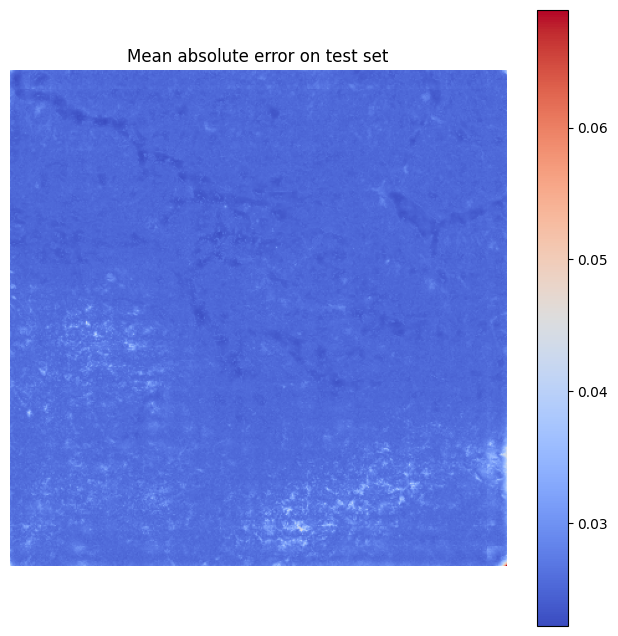

In [32]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(8, 8))

im = ax.imshow(error.squeeze(), cmap='coolwarm')
ax.set_title('Mean absolute error on test set')
ax.axis('off')
plt.colorbar(im, ax=ax)
fig.savefig('images/mae.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [9]:
trainer = L.Trainer(accelerator='cuda')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [10]:
trainer.test(model, test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/core/saving.py:363: Skipping 'model' parameter because it is not possible to safely dump to YAML.
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │   0.025749946013092995    │
│         test/mae          │    0.02574992924928665    │
│         test/mse          │   0.0009364637080579996   │
│         test/rmse         │    0.03060169517993927    │
└───────────────────────────┴───────────────────────────┘

[{'test/loss': 0.025749946013092995,
  'test/mae': 0.02574992924928665,
  'test/mse': 0.0009364637080579996,
  'test/rmse': 0.03060169517993927}]

In [11]:
ckpt = load_checkpoint(506)

model = models.EDSR.load_from_checkpoint(checkpoint_path = ckpt, channels=1, scale_factor=16, features=128, residual_blocks=64, loss=loss.LossCombination([0.9999, 0.0001], [loss.L1Loss(), loss.SoftSimpleGradientLoss(16, 'mae')])).cuda()
model.eval()

/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.


EDSR(
  (train_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=train/
  )
  (val_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=val/
  )
  (test_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=test/
  )
  (loss): LossCombination(
    (losses): ModuleList(
      (0): L1Loss(
        (l1): L1Loss()
      )
      (1): SoftSimpleGradientLoss(
        (pixel_unshuffle): PixelUnshuffle(downscale_factor=16)
        (penalization): L1Loss()
      )
    )
  )
  (head): Sequential(
    (0): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (body): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv

In [12]:
trainer = L.Trainer(accelerator='cuda')
trainer.test(model, test_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.02666318416595459    │
│         test/mae          │    0.02666552923619747    │
│         test/mse          │   0.0011426361743360758   │
│         test/rmse         │    0.03380290046334267    │
└───────────────────────────┴───────────────────────────┘

[{'test/loss': 0.02666318416595459,
  'test/mae': 0.02666552923619747,
  'test/mse': 0.0011426361743360758,
  'test/rmse': 0.03380290046334267}]

In [13]:
import lightning
import rasterio
import torch
import xarray

# Average resampling used to reduce resolution
RESAMPLING = rasterio.enums.Resampling.cubic_spline


class ReKIS(torch.utils.data.Dataset):
    """Dataset for ReKIS."""

    def __init__(self, Y: xarray.DataArray, scale_factor : int):
        """
        Initialize the dataset with target.
        The target is upscaled and used as input for the model.
        Args:
            Y : xarray.DataArray    target variable
            scale_factor : int
        """
        self.scale_factor = scale_factor

        Y = Y.isel(easting=slice(0, 400), northing=slice(0, 400))
        Y.rio.set_spatial_dims("easting", "northing")

        resolution = 1000 * self.scale_factor
        X = Y.rio.reproject(
            Y.rio.crs, resolution=(resolution, resolution), resampling=RESAMPLING
        )
        self.X = torch.from_numpy(X.values).unsqueeze(1)
        self.Y = torch.from_numpy(Y.values).unsqueeze(1)


    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, index: int):
        return self.X[index], self.Y[index]


class ReKISDataModule(lightning.LightningDataModule):
    """DataModule for ReKIS."""

    def __init__(self, batch_size: int, path: str, sets_years: list, scale_factor : int):
        """
        Initialize the DataModule.
        Args:
            batch_size : int
            path : str              path to ReKIS
            sets_years : list[int]  division of dataset into train, val and test sets
            scale_factor : int
        """
        super().__init__()
        self.batch_size = batch_size
        self.path = path
        self.sets_years = sets_years
        self.scale_factor = scale_factor

    def setup(self, stage):
        """
        Loads, splits and saves data.
        """
        variable = "TM"
        Y = xarray.open_mfdataset(self.path + variable + "/*.nc", decode_coords="all", decode_timedelta=False)
        Y = Y[variable]
        self.testset = ReKIS(Y.sel(time=slice(self.sets_years[4], self.sets_years[5])), self.scale_factor)

    def test_dataloader(self) -> torch.utils.data.DataLoader:
        """Returns a DataLoader for the test set."""
        return torch.utils.data.DataLoader(self.testset, batch_size=self.batch_size, num_workers=8)


In [14]:
PATH_ReKIS = '/home/tomas/ctu/current/rci_data/climate/ReKIS/KlimRefDS_v3.1_1961-2023/Raster/Tag/GK4/'
rekis_dm = ReKISDataModule(16, PATH_ReKIS, [ "1961", "1992", "1993", "2002", "2003", "2012" ], 16)

rekis_dm.setup(None)

test_loader = rekis_dm.test_dataloader()

In [15]:
ckpt = load_checkpoint(469)

model = models.EDSR.load_from_checkpoint(checkpoint_path = ckpt, channels=1, scale_factor=16, features=128, residual_blocks=64, loss=loss.LossCombination([1], [loss.L1Loss()])).cuda()
model.eval()

/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.


EDSR(
  (train_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=train/
  )
  (val_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=val/
  )
  (test_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=test/
  )
  (loss): LossCombination(
    (losses): ModuleList(
      (0): L1Loss(
        (l1): L1Loss()
      )
    )
  )
  (head): Sequential(
    (0): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (body): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0

In [16]:
trainer = L.Trainer(accelerator='cuda')
trainer.test(model, test_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │   0.029292097315192223    │
│         test/mae          │   0.029292091727256775    │
│         test/mse          │   0.0015101535245776176   │
│         test/rmse         │    0.03886069357395172    │
└───────────────────────────┴───────────────────────────┘

[{'test/loss': 0.029292097315192223,
  'test/mae': 0.029292091727256775,
  'test/mse': 0.0015101535245776176,
  'test/rmse': 0.03886069357395172}]